# Linear Regression

## 1. What is LinearRegression

### Core Concept
Linear regression fits a straight line (or hyperplane in multiple dimensions) through the data to model the relationship between input features and the output. It represents the machine learning problem as a linear equation where each feature has a weighted contribution to the prediction.

### Purpose
- **Task type**: Regression (predicting continuous/numeric outputs)
- **Input**: Multiple features (independent variables)
- **Output**: Single continuous value (dependent variable)
- **Examples**: Predicting house prices, temperature, sales revenue, stock prices

### Mathematical Formula
```
ŷ = b + w₁×x₁ + w₂×x₂ + w₃×x₃ + ... + wₙ×xₙ
```

Where:
- `ŷ` = predicted output (continuous value)
- `b` = bias/intercept (baseline prediction when all features are 0)
- `w₁, w₂, ..., wₙ` = weights/coefficients (importance of each feature)
- `x₁, x₂, ..., xₙ` = input features (independent variables)


### Requirements for Input Features

#### Numeric Features
- Linear regression requires **numeric input features**
- Features must be quantitative values (integers or floats)

#### Handling Categorical Variables
When you have categorical (non-numeric) features, you must convert them to numeric format:

##### One-Hot Encoding
The standard method for converting categorical variables to numeric:

**Concept**: Represent each category as binary (0/1) columns

**Rule**: For a categorical variable with `n` categories, create `n-1` dummy variables
- Why n-1? One category is the "reference" - when all dummies are 0, it represents that category
- Avoids multicollinearity (perfect correlation between features)

**example:**
```
Original data:
| Color  | Size |
|--------|------|
| Red    | 5    |
| Blue   | 7    |
| Green  | 6    |

After encoding:
| is_Blue | is_Green | Size |
|---------|----------|------|
| 0       | 0        | 5    |  ← Red (reference)
| 1       | 0        | 7    |  ← Blue
| 0       | 1        | 6    |  ← Green
```

### How Linear Regression Learns

1. **Initialize weights and bias** (randomly or to zero)
2. **Make predictions** using current weights
3. **Calculate loss** (typically Mean Squared Error)
4. **Compute gradients** (how to adjust weights)
5. **Update weights** using gradient descent
6. **Repeat** until convergence

**Loss function (MSE):**
```
Loss = (1/n) × Σ(predicted - actual)²
```

### Key Characteristics

#### Assumptions
- Linear relationship between features and output
- Features are independent of each other (no perfect multicollinearity)
- Residuals (errors) are normally distributed
- Constant variance of errors (homoscedasticity)

#### Strengths
- Simple and interpretable
- Fast to train
- Works well when relationship is truly linear
- Each weight shows feature importance

#### Limitations
- Cannot model non-linear relationships (without feature engineering)
- Sensitive to outliers
- Assumes features are independent
- Requires numeric inputs (must encode categorical variables)

## 2. Linear Regression Implementation

### 2.1 Import Libraries

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Improt the linear regression model that i will use
from sklearn.linear_model import LinearRegression
# So i can split the data into train,val,test 
from sklearn.model_selection import train_test_split
# Makes me test the accuracy and loss of model
from sklearn.metrics import mean_squared_error,r2_score 
# Get housing dataset
from sklearn.datasets import fetch_california_housing

### 2.2 Fetch Data

In [18]:
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

### 2.3 Put Data in DataFrame

In [19]:
# Convert housing data to DataFrame with named columns (Feature columns)
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### 2.4  Create Target Column

In [20]:
# Add Price column which will be the target column
df['Price'] = housing.target
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


### 2.5 Data Analysis & Feature Extraction
- Note all columns are features, here we will extract the most important ones that contribute to the model or the target column (Price)
- First we will do some data analysis so we can recognize which features arre important and which feature can be discarded.
- Note, I do feature extraction because some features can reduce the accuracy of the model and make it perform worse and they don't coontribute in a good way to the result, so we want to limit our features in order to boost the performance of the model, since not all features are usefull and can introduce overfitting

#### 2.5.1 Scatter Plot (MedInc VS Price)

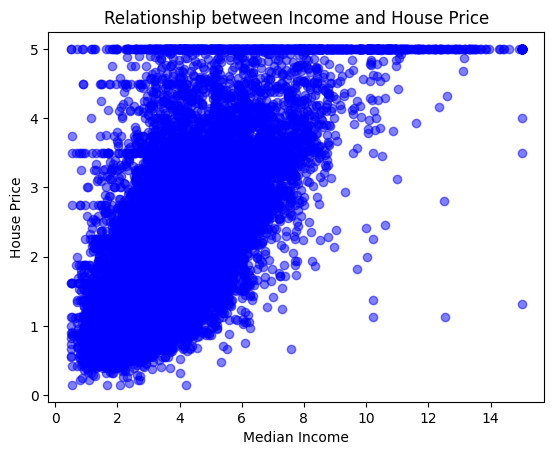


We can see a Linear relationship between Median Income with the Housing Price. 
We have a +ve Correlation. As the Income increases, the housing price increases.
Therefore, MedInc is a very important feature when it comes to predicting House Prices.



In [24]:
plt.scatter(df['MedInc'], df['Price'], color="blue", alpha=0.5)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Relationship between Income and House Price")
plt.show()

Observation = """
We can see a Linear relationship between Median Income with the Housing Price. 
We have a +ve Correlation. As the Income increases, the housing price increases.
Therefore, MedInc is a very important feature when it comes to predicting House Prices.
"""

print(Observation)

#### 2.5.2 Scatter Plot (HourseAge vs Price)

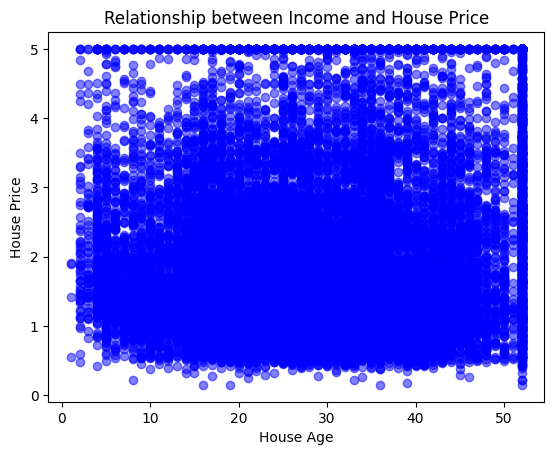


We can see no pattern emerges between HousingAge and Pricing. 
No Correlation, Very Weak Feature.



In [27]:
plt.scatter(df['HouseAge'], df['Price'], color="blue", alpha=0.5)
plt.xlabel("House Age")
plt.ylabel("House Price")
plt.title("Relationship between Income and House Price")
plt.show()

Observation = """
We can see no pattern emerges between HousingAge and Pricing. 
No Correlation, Very Weak Feature.
"""

print(Observation)

#### 2.5.3 Scatter Plot (Avg Rooms vs Price)

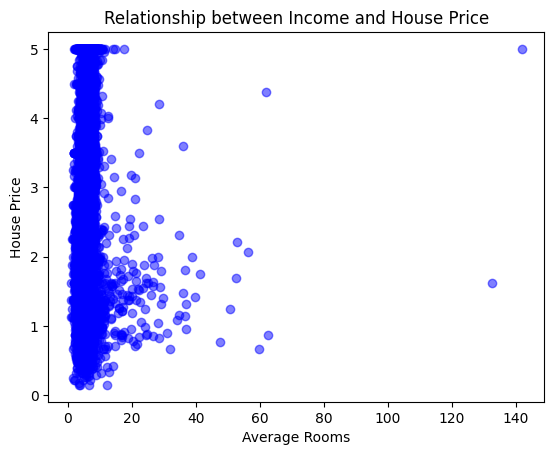


We can see no pattern emerges between Average Rooms and Pricing. 
No Strong Correlation, Very Weak Feature. However, can still be tken into consideration



In [34]:
plt.scatter(df['AveRooms'], df['Price'], color="blue", alpha=0.5)
plt.xlabel("Average Rooms")
plt.ylabel("House Price")
plt.title("Relationship between Income and House Price")
plt.show()

Observation = """
We can see no pattern emerges between Average Rooms and Pricing. 
No Strong Correlation, Very Weak Feature. However, can still be tken into consideration
"""

print(Observation)

#### 2.5.4 Scatter Plot (Avg Bedrooms vs Price)

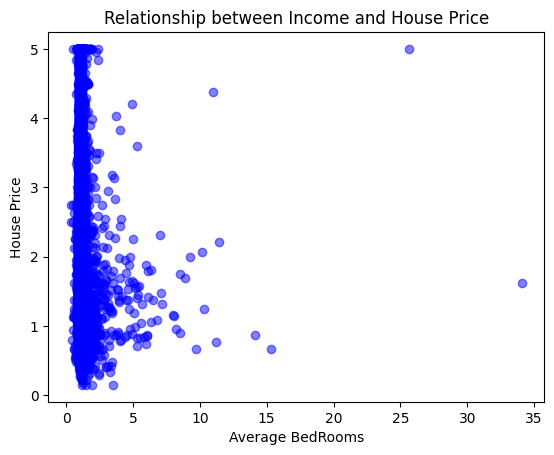


We can see no pattern emerges between Average Rooms and Pricing. 
No Correlation, Very Weak Feature.



In [ ]:
plt.scatter(df['AveBedrms'], df['Price'], color="blue", alpha=0.5)
plt.xlabel("Average BedRooms")
plt.ylabel("House Price")
plt.title("Relationship between Income and House Price")
plt.show()

Observation = """
We can see no pattern emerges between Average BedRooms and Pricing. 
No Correlation, Very Weak Feature.
"""

print(Observation)

#### 2.5.5 Scatter Plot (Occup vs Price)

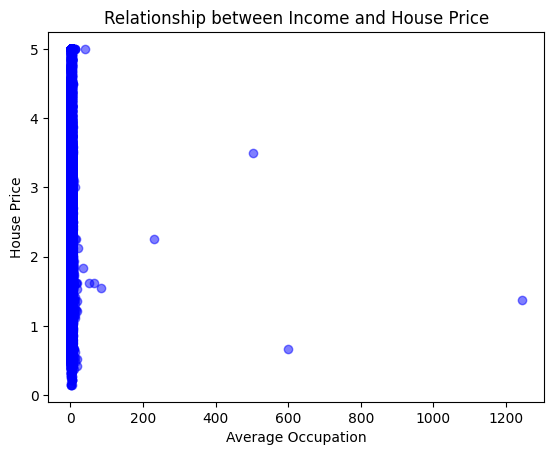


We can see no pattern emerges between Average Occupation and Pricing. 
No Correlation, Very Weak Feature.



In [33]:
plt.scatter(df['AveOccup'], df['Price'], color="blue", alpha=0.5)
plt.xlabel("Average Occupation")
plt.ylabel("House Price")
plt.title("Relationship between Income and House Price")
plt.show()

Observation = """
We can see no pattern emerges between Average Occupation and Pricing. 
No Correlation, Very Weak Feature.
"""

print(Observation)

#### 2.5.6 HeatMap

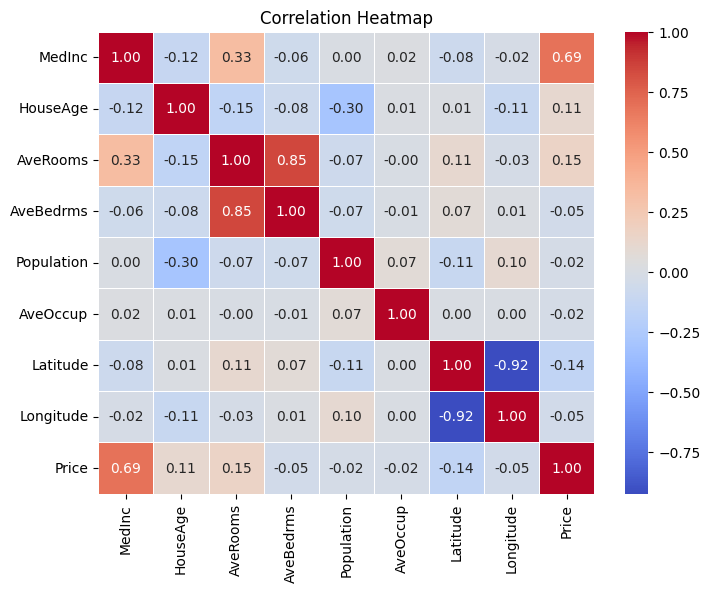


We Can see the Strongest Correlation +ve Between MedInc and Price.
Next Is HouseAge and Avg Rooms with less contribution (Weak) yet still +ve
Latitude has a -ve correlation with price yet very small almost to no correlation
Meaning when one inc the other decreases and visa versa, in my opinion no major effect
The rest resemble unnoticable correlations



In [38]:
import seaborn as sns

corr = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Observation = """
We Can see the Strongest Correlation +ve Between MedInc and Price.
Next Is HouseAge and Avg Rooms with less contribution (Weak) yet still +ve
Latitude has a -ve correlation with price yet very small almost to no correlation
Meaning when one inc the other decreases and visa versa, in my opinion no major effect
The rest resemble unnoticable correlations
"""

print(Observation)


#### 2.5.7 Features Selected Based On Analysis 

- **MedInc**: Storng +ve Correlation with Price
- **House Age** : Weak +ve Correlation with price Yet adds some contribution
- **AVG Rooms** : Weak +ve Correlation with price Yet adds some contribution

### 2.6 Data Preperation

1. Set the X Variable with the selected Feeatures (Independent Variables)
2. Set the Y Variable with the Target Feature (Dependant Variable)
3. Split the data into Train (80%), Test (20%)
    - We Take the train split for training 
    - We Take the test split for testing our model (Get Y_prediction)
    - We use the Y_Prediction from the model in order to calculate & evaluate the model's metrics (R2 Score, MSE,...)

In [ ]:
# Set the Independant and dependant Variables that will be used in our model
selected_features = ["MedInc","HouseAge","AveRooms"]
X = df[selected_features]
y= df["Price"]

# Split the data inot train, test
# Train data will be used in training and Test data will be used for testing the performance of the model
# test_size: represents what percentage of data is used for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# random_state=42
# What it does: Controls the randomness of the split to make it reproducible.
# Why it matters:
#   train_test_split randomly shuffles data before splitting
#   Without random_state: You get a different split every time you run the code
#   With random_state=42: You get the same split every time


